In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Ustawienia wyświetlania
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style="whitegrid")

print("Biblioteki załadowane")

Biblioteki załadowane


In [2]:
# Załadowanie datasetu
data = load_breast_cancer()

# Wyświetlenie pełnego opisu
print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [3]:
# Zamiana na DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Dodanie kolumny z etykietami (0 = malignant, 1 = benign)
df['target'] = data.target

# Podgląd pierwszych 5 wierszy
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.5890,153.4000,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.3800,17.3300,184.6000,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,0
1,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.3980,74.0800,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.9900,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890,0
2,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.5850,94.0300,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.5700,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,0
3,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.4450,27.2300,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.9100,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,0
4,20.2900,14.3400,135.1000,1297.0000,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.4380,94.4400,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.5400,16.6700,152.2000,1575.0000,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768,0


In [4]:
print("Kształt danych:", df.shape)
print("\nTypy danych:")
print(df.dtypes)
print("\nBrakujące wartości:")
print(df.isnull().sum().sum(), "— łącznie brakujących komórek")

Kształt danych: (569, 31)

Typy danych:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave p

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0000,14.1273,3.5240,6.9810,11.7000,13.3700,15.7800,28.1100
mean texture,569.0000,19.2896,4.3010,9.7100,16.1700,18.8400,21.8000,39.2800
mean perimeter,569.0000,91.9690,24.2990,43.7900,75.1700,86.2400,104.1000,188.5000
mean area,569.0000,654.8891,351.9141,143.5000,420.3000,551.1000,782.7000,2501.0000
mean smoothness,569.0000,0.0964,0.0141,0.0526,0.0864,0.0959,0.1053,0.1634
mean compactness,569.0000,0.1043,0.0528,0.0194,0.0649,0.0926,0.1304,0.3454
mean concavity,569.0000,0.0888,0.0797,0.0000,0.0296,0.0615,0.1307,0.4268
mean concave points,569.0000,0.0489,0.0388,0.0000,0.0203,0.0335,0.0740,0.2012
mean symmetry,569.0000,0.1812,0.0274,0.1060,0.1619,0.1792,0.1957,0.3040
mean fractal dimension,569.0000,0.0628,0.0071,0.0500,0.0577,0.0615,0.0661,0.0974


In [6]:
klasy = pd.Series(data.target).value_counts()
print("Klasa 0 — Malignant (złośliwy):", klasy[0])
print("Klasa 1 — Benign (łagodny):", klasy[1])
print(f"\nProporcja: {klasy[0]/klasy[1]:.2f} — na każdy łagodny przypadek przypada tyle złośliwych")

Klasa 0 — Malignant (złośliwy): 212
Klasa 1 — Benign (łagodny): 357

Proporcja: 0.59 — na każdy łagodny przypadek przypada tyle złośliwych


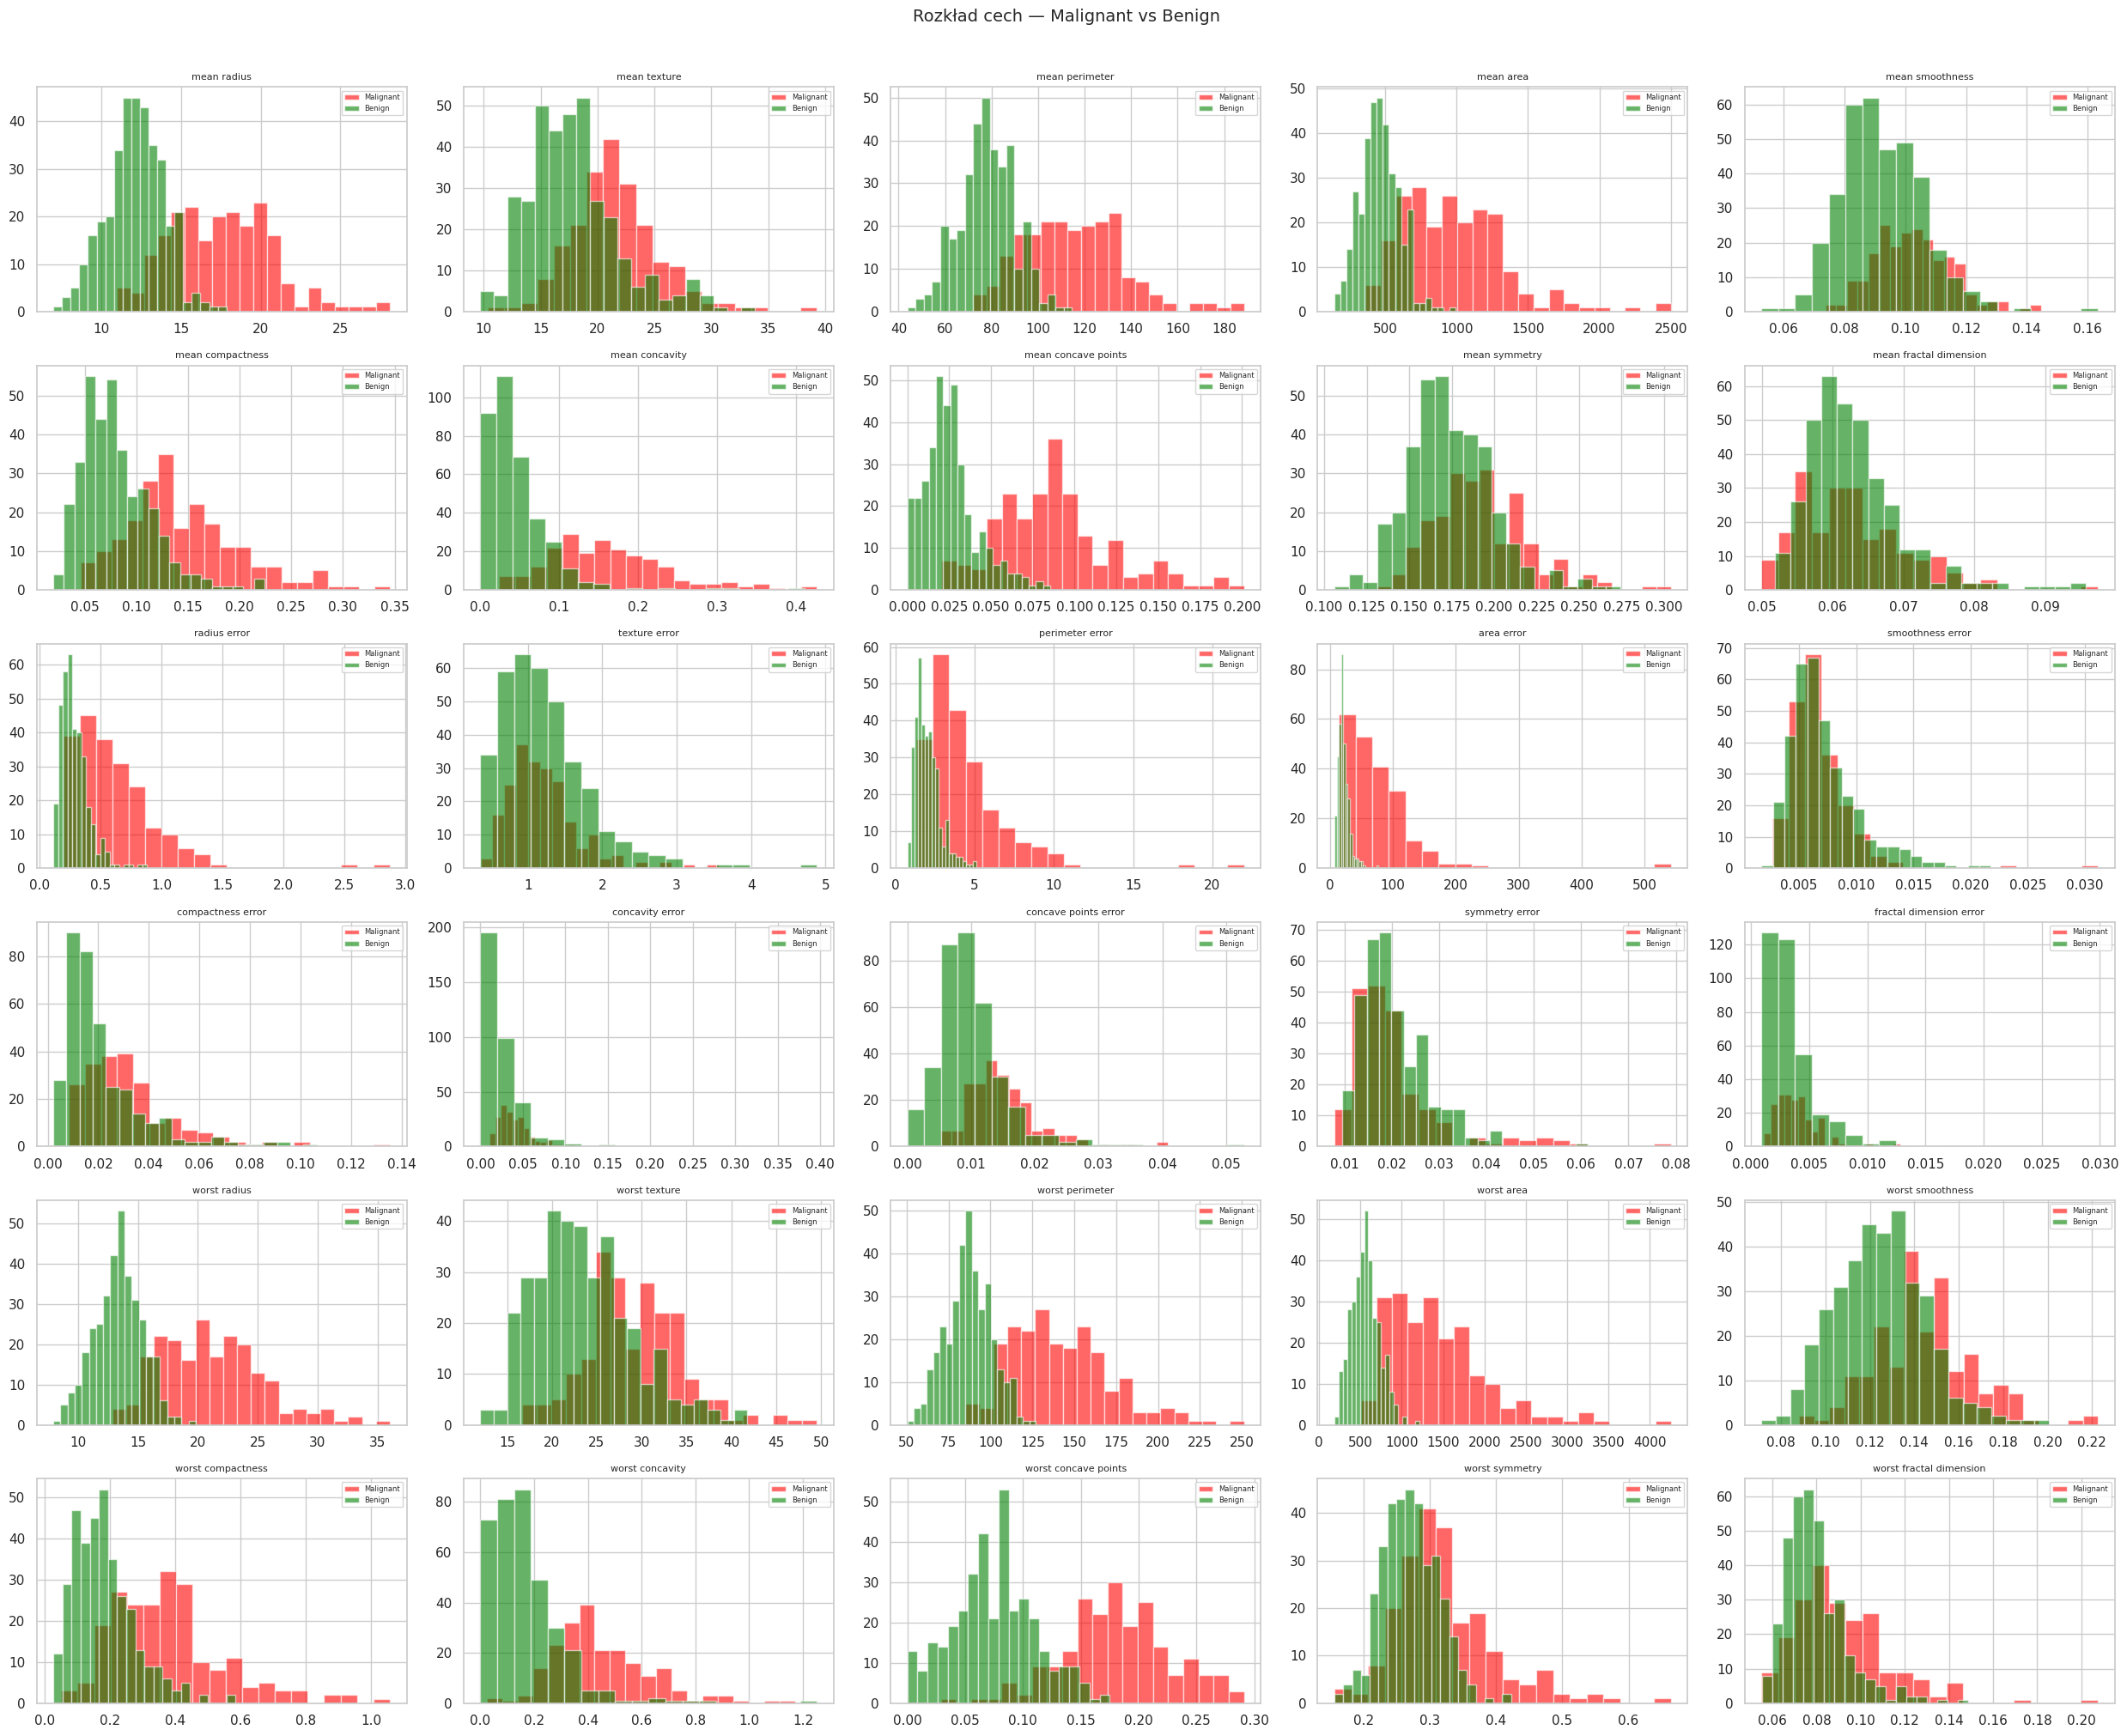

Wykresy zapisują się w results/plots/


In [7]:
fig, axes = plt.subplots(6, 5, figsize=(25, 20))
axes = axes.flatten()

for i, col in enumerate(data.feature_names):
    axes[i].hist(df[df['target'] == 0][col], bins=20, alpha=0.6, color='red', label='Malignant')
    axes[i].hist(df[df['target'] == 1][col], bins=20, alpha=0.6, color='green', label='Benign')
    axes[i].set_title(col, fontsize=8)
    axes[i].legend(fontsize=6)

plt.suptitle('Rozkład cech — Malignant vs Benign', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../results/plots/histogramy.png', bbox_inches='tight')
plt.show()

print("Wykresy zapisują się w results/plots/")

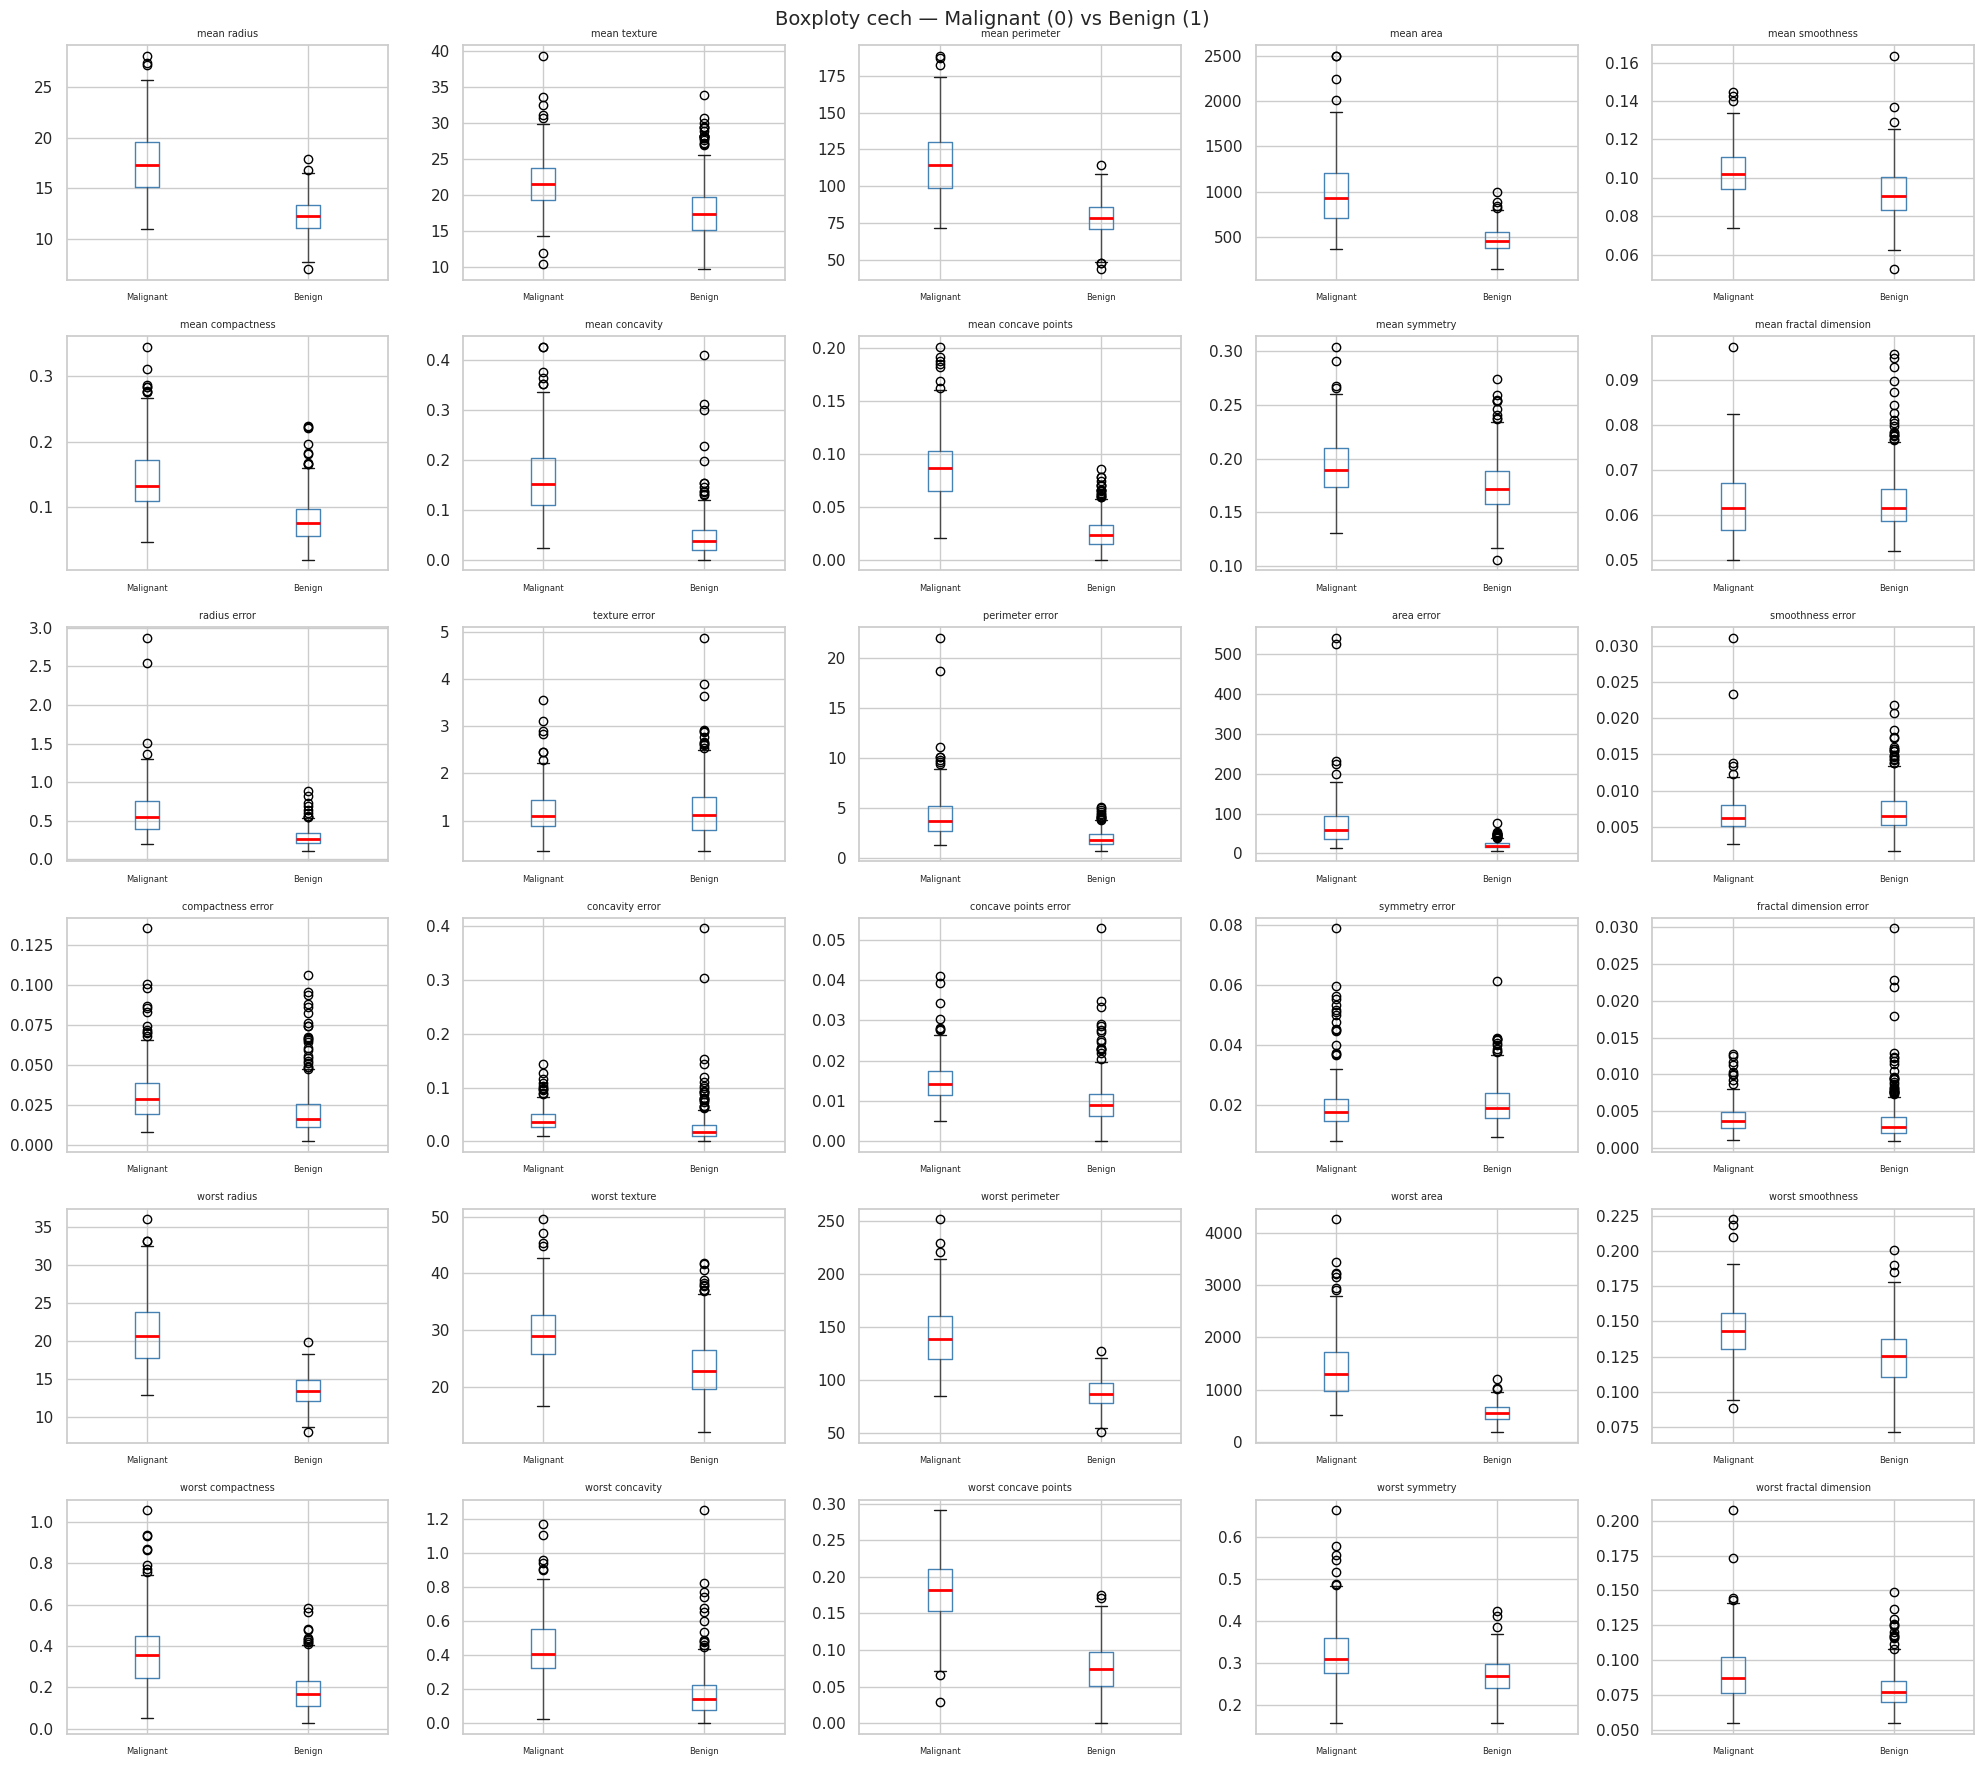

✅ Wykres zapisany do results/plots/


In [8]:
fig, axes = plt.subplots(6, 5, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(data.feature_names):
    df.boxplot(
        column=col,
        by='target',
        ax=axes[i],
        boxprops=dict(color='steelblue'),
        medianprops=dict(color='red', linewidth=2)
    )
    axes[i].set_title(col, fontsize=7)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['Malignant', 'Benign'], fontsize=6)

plt.suptitle('Boxploty cech — Malignant (0) vs Benign (1)', fontsize=14)
plt.tight_layout()
plt.savefig('../results/plots/boxploty.png', bbox_inches='tight')
plt.show()

print("✅ Wykres zapisany do results/plots/")

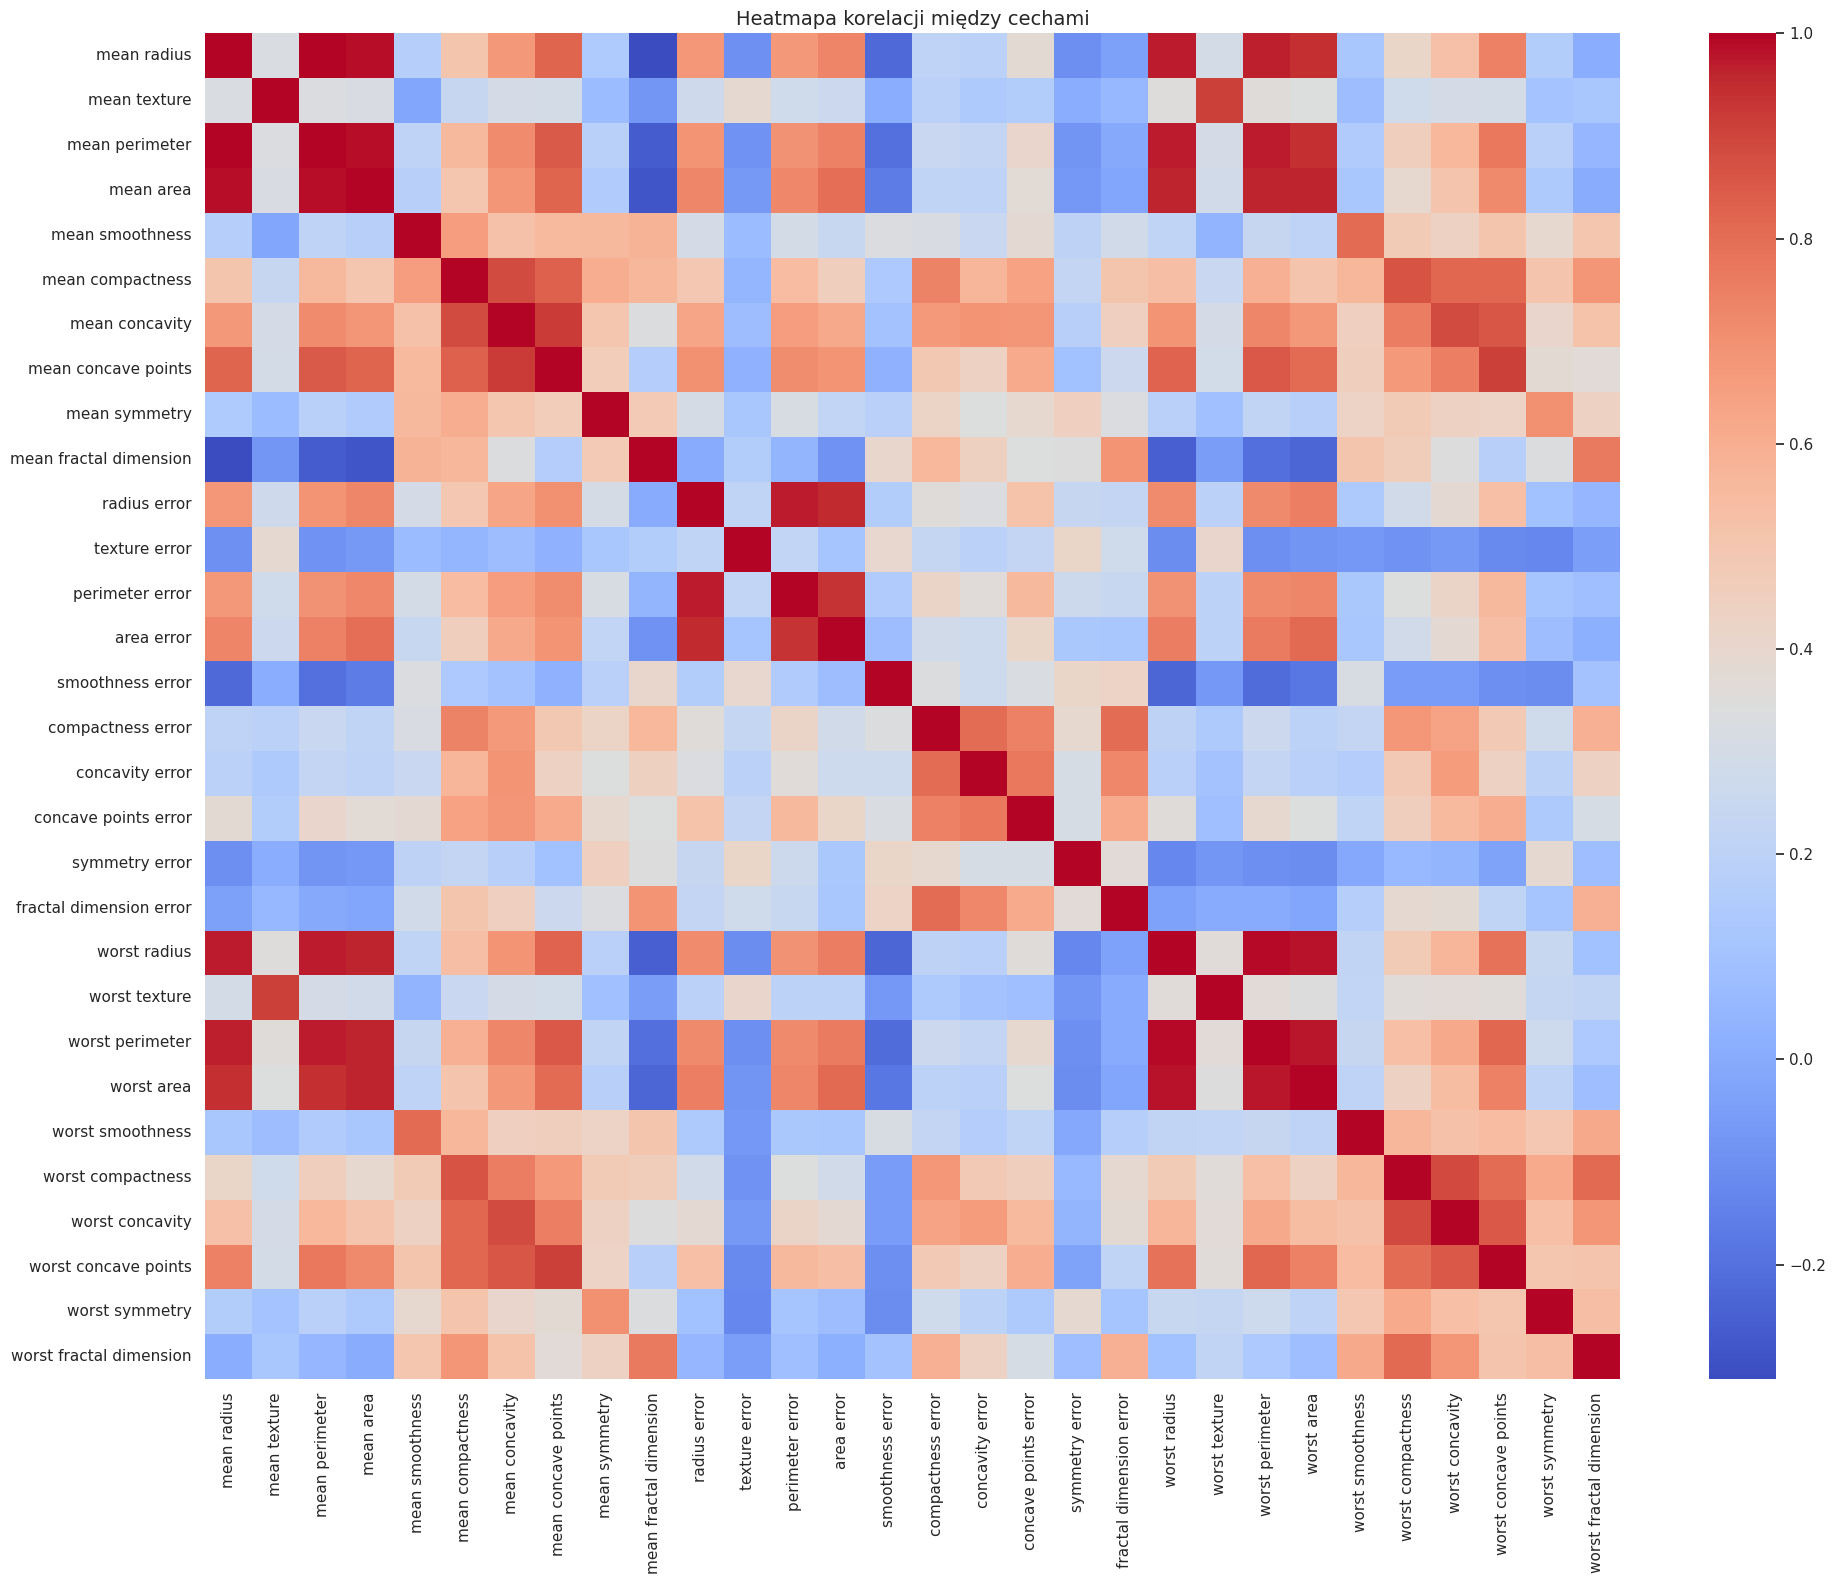

Wykresy zapisują się w results/plots/


In [13]:
plt.figure(figsize=(20, 16))
korelacja = df.drop('target', axis=1).corr()

sns.heatmap(
    korelacja, 
    annot=False,
    cmap='coolwarm', #niebieski = ujemna, czerwony = dodatnia korelacja center=0, square=True, linewidths=0.3 
)

plt.title('Heatmapa korelacji między cechami', fontsize=14) 
plt.tight_layout() 
plt.savefig('../results/plots/heatmapa.png', bbox_inches='tight') 
plt.show()

print("Wykresy zapisują się w results/plots/")

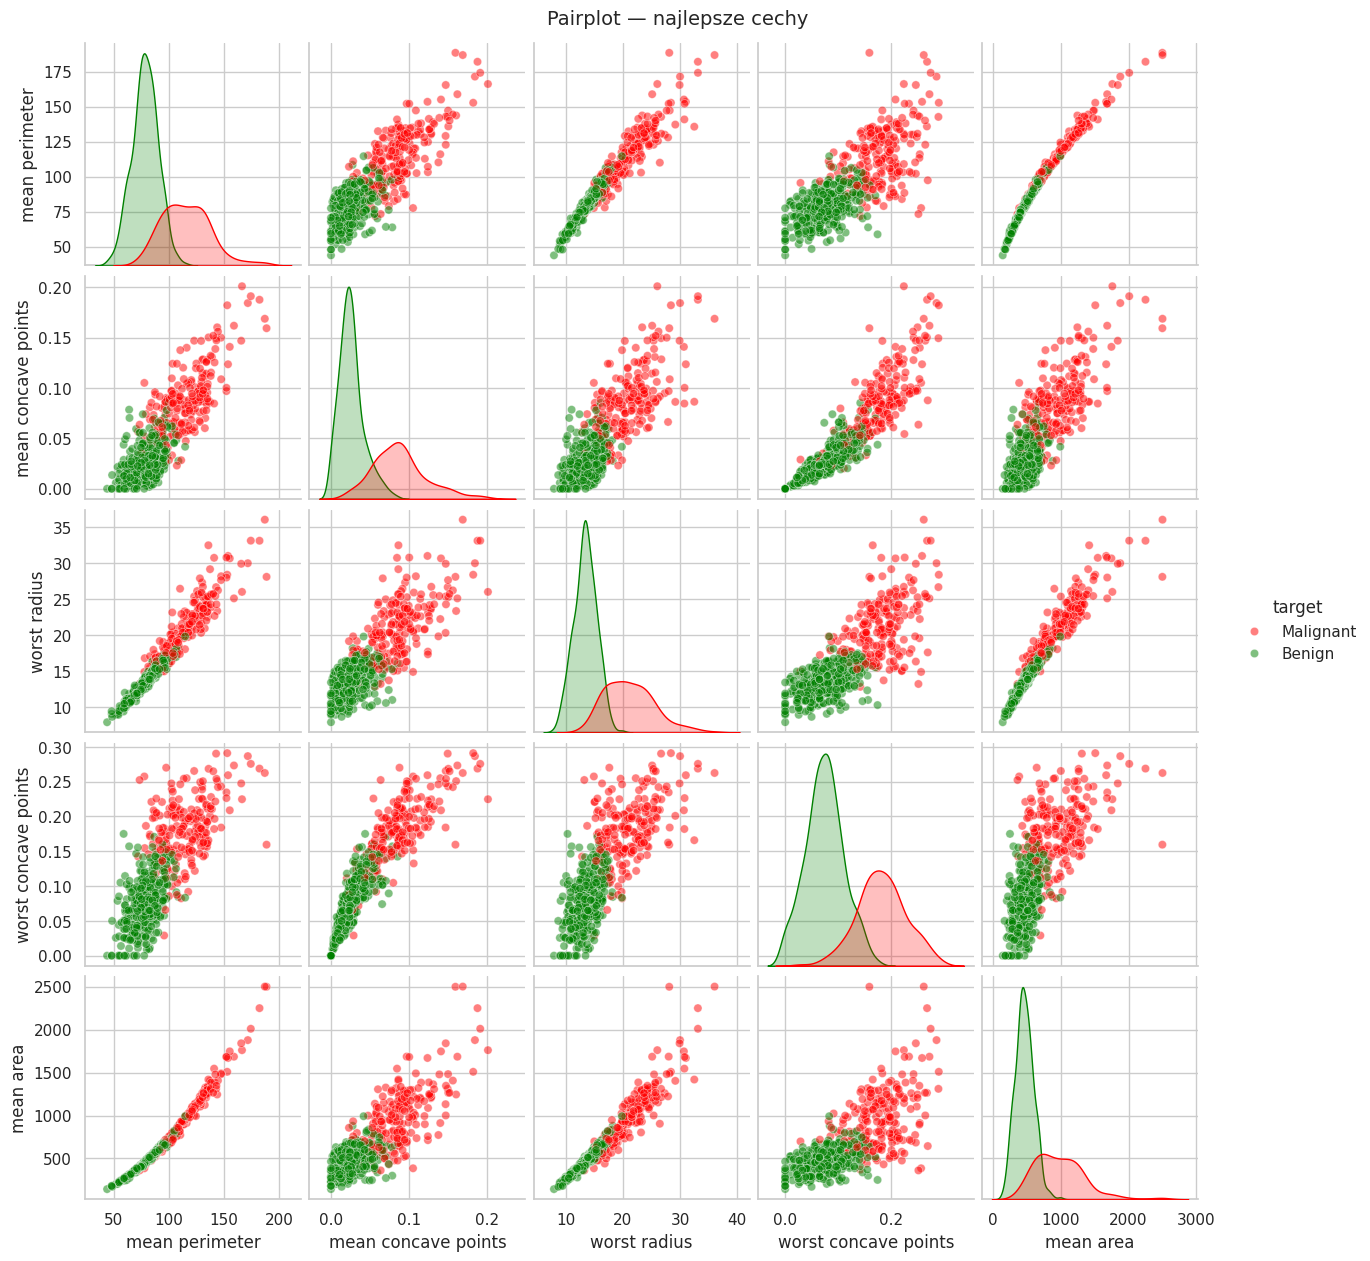

✅ Wykres zapisany do results/plots/


In [12]:
najlepsze_cechy = [
    'mean perimeter',
    'mean concave points',
    'worst radius',
    'worst concave points',
    'mean area',
    'target'
]

df_pair = df[najlepsze_cechy].copy()
df_pair['target'] = df_pair['target'].map({0: 'Malignant', 1: 'Benign'})

sns.pairplot(
    df_pair,
    hue='target',
    palette={'Malignant': 'red', 'Benign': 'green'},
    plot_kws={'alpha': 0.5},
    diag_kind='kde'
)

plt.suptitle('Pairplot — najlepsze cechy', fontsize=14, y=1.01)
plt.savefig('../results/plots/pairplot.png', bbox_inches='tight')
plt.show()

print("✅ Wykres zapisany do results/plots/")